In [22]:
import os
import time
import random
import timm
import copy
import torchvision
from torchvision import datasets, transforms
import torchvision.models as models
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def seed_all(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

batch_size = 64
seed = 123
seed_all(seed)

simclr_epochs = 200
s_learning_rate = 1e-3

clf_epochs = 50
num_class = 3

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
print(torch.cuda.is_available())
print(torch.__version__)
print(torch.version.cuda)

True
2.11.0+cu128
12.8


In [24]:
# Part1.Dataset

from pathlib import Path
from typing import List, Sequence, Optional
from PIL import Image, ImageOps
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF

class Clsdata(Dataset):
    def __init__(
        self,
        root_list: Sequence[str], # front images path list
        cls_to_idx,
        shuffle: bool = True,
        transform=None,
        train: bool = False,
        test: bool = False,
        img_size: int = 224,
    ):
        assert not (train and test), "Both train and test cannot be True at the same time"
        self.test = test
        self.train = train
        self.img_size = int(img_size)

        lines: List[Path] = [Path(p) for p in root_list]
        if shuffle:
            random.shuffle(lines)
        self.lines = lines
        self.nSamples = len(self.lines)

        self.mean = (0.485, 0.456, 0.406)
        self.std  = (0.229, 0.224, 0.225)

        if transform is None:
            if self.train and not self.test:
                self.transform = None
            else:
                # val / test：
                self.transform = transforms.Compose([
                    transforms.Resize((self.img_size, self.img_size)),
                    transforms.ToTensor(),
                    transforms.Normalize(self.mean, self.std),
                ])
        else:
            self.transform = transform

        self.cls_to_idx = cls_to_idx
        self.idx_to_cls = {v: k for k, v in self.cls_to_idx.items()}

    def __len__(self):
        return self.nSamples

    def _pair_transform(self, img1_pil: Image.Image, img2_pil: Image.Image):
        img1 = ImageOps.exif_transpose(img1_pil)
        img2 = ImageOps.exif_transpose(img2_pil)

        img1 = TF.resize(img1, [self.img_size, self.img_size])
        img2 = TF.resize(img2, [self.img_size, self.img_size])

        if random.random() < 0.5:
            img1 = TF.hflip(img1)
            img2 = TF.hflip(img2)

        if random.random() < 0.5:
            img1 = TF.vflip(img1)
            img2 = TF.vflip(img2)

        if random.random() < 0.8:
            b = 1.0 + random.uniform(-0.2, 0.2)  # brightness factor
            c = 1.0 + random.uniform(-0.2, 0.2)  # contrast factor
            s = 1.0 + random.uniform(-0.2, 0.2)  # saturation factor
            h = random.uniform(-0.05, 0.05)      # hue delta

            img1 = TF.adjust_brightness(img1, b); img2 = TF.adjust_brightness(img2, b)
            img1 = TF.adjust_contrast(img1, c);   img2 = TF.adjust_contrast(img2, c)
            img1 = TF.adjust_saturation(img1, s); img2 = TF.adjust_saturation(img2, s)
            img1 = TF.adjust_hue(img1, h);        img2 = TF.adjust_hue(img2, h)

        # ToTensor + Normalize
        img1 = TF.to_tensor(img1); img2 = TF.to_tensor(img2)
        img1 = TF.normalize(img1, self.mean, self.std)
        img2 = TF.normalize(img2, self.mean, self.std)
        return img1, img2

    def __getitem__(self, index: int):
        assert 0 <= index < len(self), f'index out of range: {index} / {len(self)}'

        img_path = self.lines[index]
        # front / side
        img1_path = img_path
        img2_path = Path(str(img_path).replace("front.jpg", "side.jpg"))

        img1_pil = Image.open(img1_path).convert('RGB')
        img2_pil = Image.open(img2_path).convert('RGB')

        if self.train and not self.test and self.transform is None:
            img1, img2 = self._pair_transform(img1_pil, img2_pil)
        else:
            img1  = self.transform(img1_pil)
            img2 = self.transform(img2_pil)

        class_name = Path(img_path).parent.parent.name
        label = self.cls_to_idx[class_name]

        return img1, img2, label

In [25]:
# Part2. train/val/test 분할

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_root = r"/home/airl02/Desktop/ParkJeongEun/PediURF/train"
test_root = r"/home/airl02/Desktop/ParkJeongEun/PediURF/test"

cls_to_idx = {
    "Proximal ulna and radius fractures": 0,
    "Midshaft ulna and radius fractures": 1,
    "Distal ulna and radius fractures": 2,
}

def get_all_imgs_path(root: str):
  root = Path(root)
  all_front_path = [str(p) for p in root.rglob("front.jpg")]
  return all_front_path

def get_label_from_path(img_path: str):
  path = Path(img_path)
  class_name = path.parent.parent.name

  if class_name not in cls_to_idx:
    raise ValueError(f"Unknown class folder name: {class_name}")

  return cls_to_idx[class_name]

def make_stratified_split(train_root, val_ratio=0.2, seed=123):
  all_imgs_path = get_all_imgs_path(train_root)

  all_labels = [get_label_from_path(p) for p in all_imgs_path]

  train_imgs_path, val_imgs_path = train_test_split(
      all_imgs_path,
      test_size=val_ratio,
      random_state=seed,
      stratify=all_labels
  )

  return train_imgs_path, val_imgs_path

# 8:2 split
train_imgs_path, val_imgs_path = make_stratified_split(
    train_root = train_root,
    val_ratio=0.2,
    seed=seed
)

test_imgs_path = get_all_imgs_path(test_root)

train_data = Clsdata(train_imgs_path, cls_to_idx, train=True, shuffle=True)
val_data  = Clsdata(val_imgs_path, cls_to_idx, train=False, shuffle=False, test=True)
test_data = Clsdata(test_imgs_path, cls_to_idx, train=False, shuffle=False, test=True)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

train_length = len(train_data)
val_length  = len(val_data)
test_length = len(test_data)

print(f"train_length: {train_length}")
print(f"val_length: {val_length}")
print(f"test_length: {test_length}")

train_length: 3369
val_length: 843
test_length: 1053


In [26]:
# Part3. Encoder (SimCLR)

from torchvision.models import ResNet34_Weights

class SimCLR(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        self.encoder = models.resnet34(weights=ResNet34_Weights.DEFAULT)
        self.encoder.fc = nn.Identity()

        # Projection Head: 이 공간에서만 Contrastive Learning 수행
        self.projection_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, proj_dim)
        )

    def forward(self, x1, x2):
        features1 = self.encoder(x1)
        features2 = self.encoder(x2)

        z1 = F.normalize(self.projection_head(features1))
        z2 = F.normalize(self.projection_head(features2))

        return z1, z2

simclr_model = SimCLR().to(device)

In [27]:
def nt_xent_loss(z1, z2, temperature=0.07):    # tempearature 값이 성능좌우
    B = z1.shape[0]
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    z = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.T) / temperature
    mask = torch.eye(2 * B, dtype=torch.bool).to(z.device)
    sim.masked_fill_(mask, float('-inf'))
    labels = torch.cat([
        torch.arange(B, 2*B),
        torch.arange(0, B)
    ]).to(z.device)
    return F.cross_entropy(sim, labels)

In [28]:
# Part4. SimCLR 학습
from sklearn.metrics import f1_score
from datetime import datetime

save_name = f"ResNet34_Best_SimCLR_Backbone.pth"
best_model_path = os.path.join("/home/airl02/Desktop/ParkJeongEun/Model", save_name)

simclr_optimizer = torch.optim.SGD(simclr_model.parameters(), lr=s_learning_rate, momentum=0.9, weight_decay=1e-4)
simclr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(simclr_optimizer, T_max=simclr_epochs)

train_losses, val_losses = [], []

best_val_loss = float('inf')
start_epoch = 0

if os.path.exists(best_model_path):
  checkpoint = torch.load(best_model_path, map_location=device)

  simclr_model.load_state_dict(checkpoint['model_state_dict'])
  simclr_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
  simclr_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
  start_epoch   = checkpoint.get('epoch', -1) + 1
  train_losses  = checkpoint.get('train_losses', [])
  val_losses    = checkpoint.get('val_losses', [])
  best_val_loss   = checkpoint.get('best_val_loss', float('inf'))

  print(f"Restart from epoch {start_epoch}")

for epoch in range(start_epoch, simclr_epochs):
    simclr_model.train()
    total_train_loss = 0.0

    for img1, img2, _ in train_loader:
        img1 = img1.to(device)
        img2 = img2.to(device)

        simclr_optimizer.zero_grad()

        z1, z2 = simclr_model(img1, img2)

        loss = nt_xent_loss(z1, z2)
        loss.backward()
        simclr_optimizer.step()

        total_train_loss += loss.item() * img1.size(0)

    train_loss = total_train_loss / train_length
    train_losses.append(train_loss)

    simclr_scheduler.step()

    simclr_model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
      for img1, img2, label in val_loader:
          img1, img2, label = img1.to(device), img2.to(device), label.to(device)

          z1, z2 = simclr_model(img1, img2)

          loss = nt_xent_loss(z1, z2)
          total_val_loss += loss.item() * img1.size(0)

    val_loss = total_val_loss / val_length
    val_losses.append(val_loss)

    print(f"[{datetime.now().strftime('%H:%M:%S')}] Epoch [{epoch+1}/{simclr_epochs}] "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
      best_val_loss = val_loss
      torch.save({
          'epoch': epoch,
          'model_state_dict': simclr_model.state_dict(),
          'optimizer_state_dict': simclr_optimizer.state_dict(),
          'scheduler_state_dict': simclr_scheduler.state_dict(),
          'train_losses': train_losses,
          'val_losses': val_losses,
          'best_val_loss': val_loss
      }, best_model_path)

[15:29:50] Epoch [1/200] Train Loss: 3.0998 | Val Loss: 2.7503
[15:30:37] Epoch [2/200] Train Loss: 1.1426 | Val Loss: 2.0025
[15:31:27] Epoch [3/200] Train Loss: 0.6792 | Val Loss: 1.8366
[15:32:15] Epoch [4/200] Train Loss: 0.5090 | Val Loss: 1.6972
[15:33:04] Epoch [5/200] Train Loss: 0.4124 | Val Loss: 1.5027
[15:33:50] Epoch [6/200] Train Loss: 0.3565 | Val Loss: 1.4714
[15:34:35] Epoch [7/200] Train Loss: 0.3054 | Val Loss: 1.4038
[15:35:20] Epoch [8/200] Train Loss: 0.2812 | Val Loss: 1.4472
[15:36:06] Epoch [9/200] Train Loss: 0.2425 | Val Loss: 1.3366
[15:36:53] Epoch [10/200] Train Loss: 0.2204 | Val Loss: 1.3595
[15:37:38] Epoch [11/200] Train Loss: 0.2012 | Val Loss: 1.2487
[15:38:24] Epoch [12/200] Train Loss: 0.1979 | Val Loss: 1.2357
[15:39:09] Epoch [13/200] Train Loss: 0.1823 | Val Loss: 1.2312
[15:39:54] Epoch [14/200] Train Loss: 0.1677 | Val Loss: 1.1791
[15:40:40] Epoch [15/200] Train Loss: 0.1527 | Val Loss: 1.1673
[15:41:27] Epoch [16/200] Train Loss: 0.1512 | Va

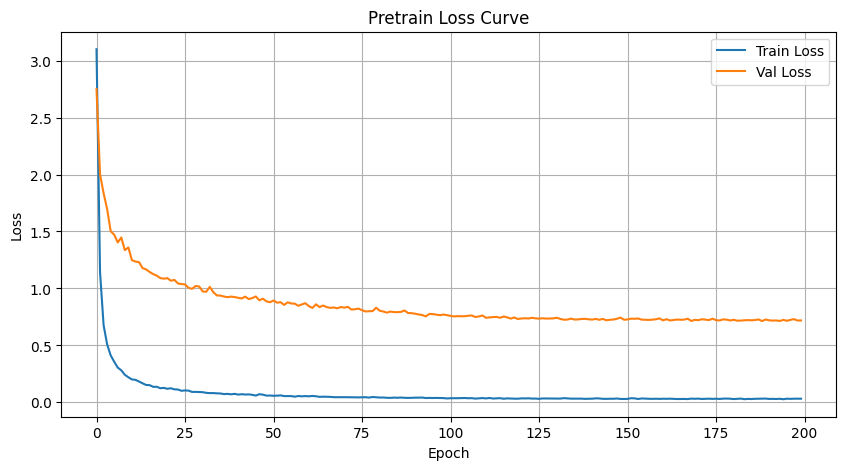

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pretrain Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

✅ KNN Top-1 Accuracy: 100.00%
Running t-SNE (this may take a while)...


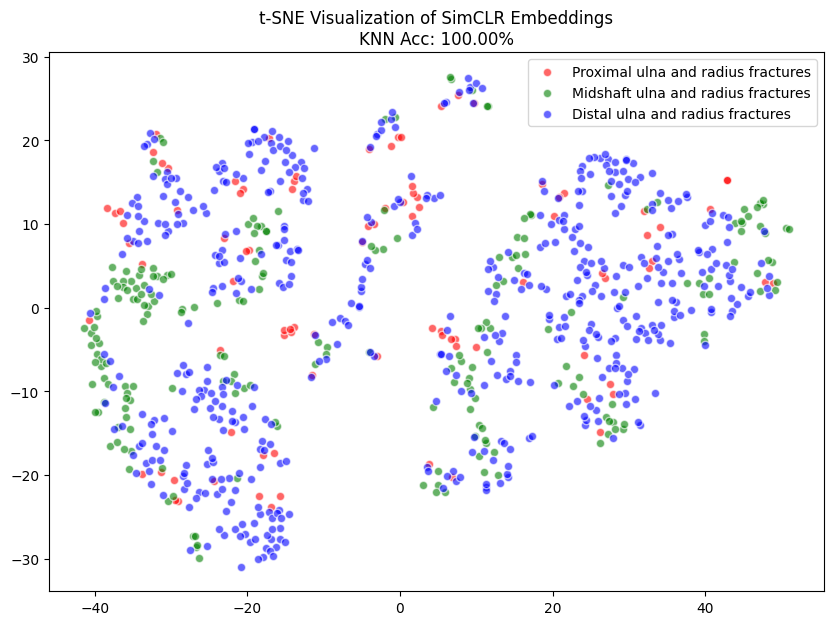

In [33]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import torch

def evaluate_embeddings(pretrain_model, val_loader, device):
    pretrain_model.eval()
    targets_list = []
    embeddings_list = []

    with torch.no_grad():
        for img1, img2, label in val_loader:
            img1, img2 = img1.to(device), img2.to(device)

            # 모델의 forward 구조에 따라 수정 (z1, z2를 얻음)
            z1, z2 = pretrain_model(img1, img2)

            # 두 뷰의 특징을 평균내거나 하나만 사용 (여기서는 평균 사용)
            z_avg = (z1 + z2) / 2

            embeddings_list.append(z_avg.cpu().numpy())
            targets_list.append(label.numpy())

    embeddings = np.concatenate(embeddings_list, axis=0)
    targets = np.concatenate(targets_list, axis=0)

    # 1. KNN Accuracy 계산 (1-Nearest Neighbor)
    # 데이터를 반으로 나눠서 학습/테스트로 시뮬레이션하거나 전체로 적합도 확인
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(embeddings, targets)
    knn_acc = knn.score(embeddings, targets)
    print(f"✅ KNN Top-1 Accuracy: {knn_acc*100:.2f}%")

    # 2. t-SNE 시각화
    print("Running t-SNE (this may take a while)...")
    tsne = TSNE(n_components=2, random_state=seed, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 7))
    classes = list(cls_to_idx.keys())
    colors = ['r', 'g', 'b']

    for i, cls_name in enumerate(classes):
        idx = np.where(targets == i)
        plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1],
                    c=colors[i], label=cls_name, alpha=0.6, edgecolors='w')

    plt.legend()
    plt.title(f"t-SNE Visualization of SimCLR Embeddings\nKNN Acc: {knn_acc*100:.2f}%")
    plt.show()

evaluate_embeddings(simclr_model, val_loader, device)

In [34]:
# Part5. Classification

save_name = f"ResNet34_Best_SimCLR_Backbone.pth"
best_simclr_path = os.path.join("/home/airl02/Desktop/ParkJeongEun/Model", save_name)

class SimCLRClassifier(nn.Module):
    def __init__(self, best_simclr_path, num_classes=3):
        super(SimCLRClassifier, self).__init__()

        # 1. Stage 1에서 저장한 모델 로드
        backbone = SimCLR()
        checkpoint = torch.load(best_simclr_path, map_location=device)
        backbone.load_state_dict(checkpoint['model_state_dict'])

        # Encoder(ResNet34)만 추출
        self.encoder = backbone.encoder

        self.cross_attention = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)

        # 3. 최종 분류기 (MLP)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x1, x2):
        features1 = self.encoder(x1)
        features2 = self.encoder(x2)

        features = torch.stack([features1, features2], dim=1)
        attn_output, _ = self.cross_attention(features, features, features)

        x = attn_output.mean(dim=1)

        logits = self.classifier(x)
        return logits

finetune_model = SimCLRClassifier(best_simclr_path).to(device)

In [35]:
# 1. Stage 2용 약한 증강 (Weak Augmentation) 정의
finetune_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# 2. Validation/Test용 (증강 아예 없음)
test_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

ft_train_data = Clsdata(train_imgs_path, cls_to_idx, train=False, transform=finetune_transformer)
ft_val_data   = Clsdata(val_imgs_path, cls_to_idx, train=False, transform=test_transformer)
ft_test_data  = Clsdata(test_imgs_path, cls_to_idx, train=False, transform=test_transformer)

ft_train_loader = DataLoader(ft_train_data, batch_size=batch_size, shuffle=True, num_workers=2)
ft_val_loader = DataLoader(ft_val_data, batch_size=batch_size, shuffle=False, num_workers=2)
ft_test_loader  = DataLoader(ft_test_data, batch_size=batch_size, shuffle=False, num_workers=2)

train_length = len(ft_train_data)
val_length  = len(ft_val_data)
test_length = len(ft_test_data)

print(f"train_length: {train_length}")
print(f"val_length: {val_length}")
print(f"test_length: {test_length}")

train_length: 3369
val_length: 843
test_length: 1053


In [36]:
from sklearn.metrics import f1_score
from datetime import datetime

save_name = f"ResNet34_Best_SimCLR_Full_Cross.pth"
best_model_path = os.path.join("/home/airl02/Desktop/ParkJeongEun/Model", save_name)

encoder_lr = 1e-6
classifier_lr = 1e-5

label_smoothing = 0.1

params_to_optimize = [
    {'params': finetune_model.encoder.parameters(), 'lr': encoder_lr},
    {'params': finetune_model.cross_attention.parameters(), 'lr': classifier_lr},
    {'params': finetune_model.classifier.parameters(), 'lr': classifier_lr}
]

criterion_ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer_ce = torch.optim.Adam(params_to_optimize, weight_decay=1e-2)

scheduler_ce = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ce, T_max=clf_epochs)

train_losses, val_losses = [], []
best_val_f1 = 0.0

patience = 10
early_stop_counter = 0

start_epoch = 0

if os.path.exists(best_model_path):
  checkpoint = torch.load(best_model_path, map_location=device)

  finetune_model.load_state_dict(checkpoint['model_state_dict'])
  optimizer_ce.load_state_dict(checkpoint['optimizer_state_dict'])
  scheduler_ce.load_state_dict(checkpoint['scheduler_state_dict'])
  start_epoch   = checkpoint.get('epoch', -1) + 1
  train_losses  = checkpoint.get('train_losses', [])
  val_losses    = checkpoint.get('val_losses', [])
  best_val_f1   = checkpoint.get('best_val_f1', 0.0)
  early_stop_counter = checkpoint.get('early_stop_counter', 0)

  print(f"Restart from epoch {start_epoch}")

for epoch in range(start_epoch, clf_epochs):
  finetune_model.train()
  total_train_loss = 0.0

  for img1, img2, label in ft_train_loader:
    img1, img2, label = img1.to(device), img2.to(device), label.to(device)
    optimizer_ce.zero_grad()

    logits = finetune_model(img1, img2)
    loss = criterion_ce(logits, label)
    loss.backward()
    optimizer_ce.step()

    total_train_loss += loss.item() * img1.size(0)

  train_loss = total_train_loss / train_length
  train_losses.append(train_loss)

  scheduler_ce.step()

  finetune_model.eval()
  all_preds, all_labels = [], []
  total_val_loss = 0.0

  with torch.no_grad():
    for img1, img2, label in ft_val_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        logits = finetune_model(img1, img2)

        loss = criterion_ce(logits, label)
        total_val_loss += loss.item() * img1.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

  val_f1 = f1_score(all_labels, all_preds, average='weighted')
  val_loss = total_val_loss / val_length
  val_losses.append(val_loss)

  print(f"[{datetime.now().strftime('%H:%M:%S')}] [Epoch {epoch+1}] "
    f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}")

  if best_val_f1 < val_f1:
      best_val_f1 = val_f1
      early_stop_counter = 0

      torch.save({
          'epoch': epoch,
          'model_state_dict': finetune_model.state_dict(),
          'optimizer_state_dict': optimizer_ce.state_dict(),
          'scheduler_state_dict': scheduler_ce.state_dict(),
          'train_losses': train_losses,
          'val_losses': val_losses,
          'best_val_f1': best_val_f1,
          'early_stop_counter': 0
      }, best_model_path)

      print(f"Best model saved! (Val F1: {best_val_f1:.4f})")

  else:
      early_stop_counter += 1

      if early_stop_counter >= patience:
        print(f"Early stopping trigerred at epoch {epoch+1}")
        break

[20:12:03] [Epoch 1] Train Loss: 0.9556, Val Loss: 0.8621, Val F1: 0.5083
Best model saved! (Val F1: 0.5083)
[20:12:47] [Epoch 2] Train Loss: 0.8372, Val Loss: 0.8067, Val F1: 0.6666
Best model saved! (Val F1: 0.6666)
[20:13:31] [Epoch 3] Train Loss: 0.7760, Val Loss: 0.7574, Val F1: 0.7072
Best model saved! (Val F1: 0.7072)
[20:14:15] [Epoch 4] Train Loss: 0.7362, Val Loss: 0.7115, Val F1: 0.7302
Best model saved! (Val F1: 0.7302)
[20:14:58] [Epoch 5] Train Loss: 0.6924, Val Loss: 0.6775, Val F1: 0.7500
Best model saved! (Val F1: 0.7500)
[20:15:42] [Epoch 6] Train Loss: 0.6589, Val Loss: 0.6531, Val F1: 0.7579
Best model saved! (Val F1: 0.7579)
[20:16:26] [Epoch 7] Train Loss: 0.6381, Val Loss: 0.6361, Val F1: 0.7627
Best model saved! (Val F1: 0.7627)
[20:17:09] [Epoch 8] Train Loss: 0.6219, Val Loss: 0.6217, Val F1: 0.7702
Best model saved! (Val F1: 0.7702)
[20:17:55] [Epoch 9] Train Loss: 0.6031, Val Loss: 0.6124, Val F1: 0.7793
Best model saved! (Val F1: 0.7793)
[20:18:39] [Epoch 1

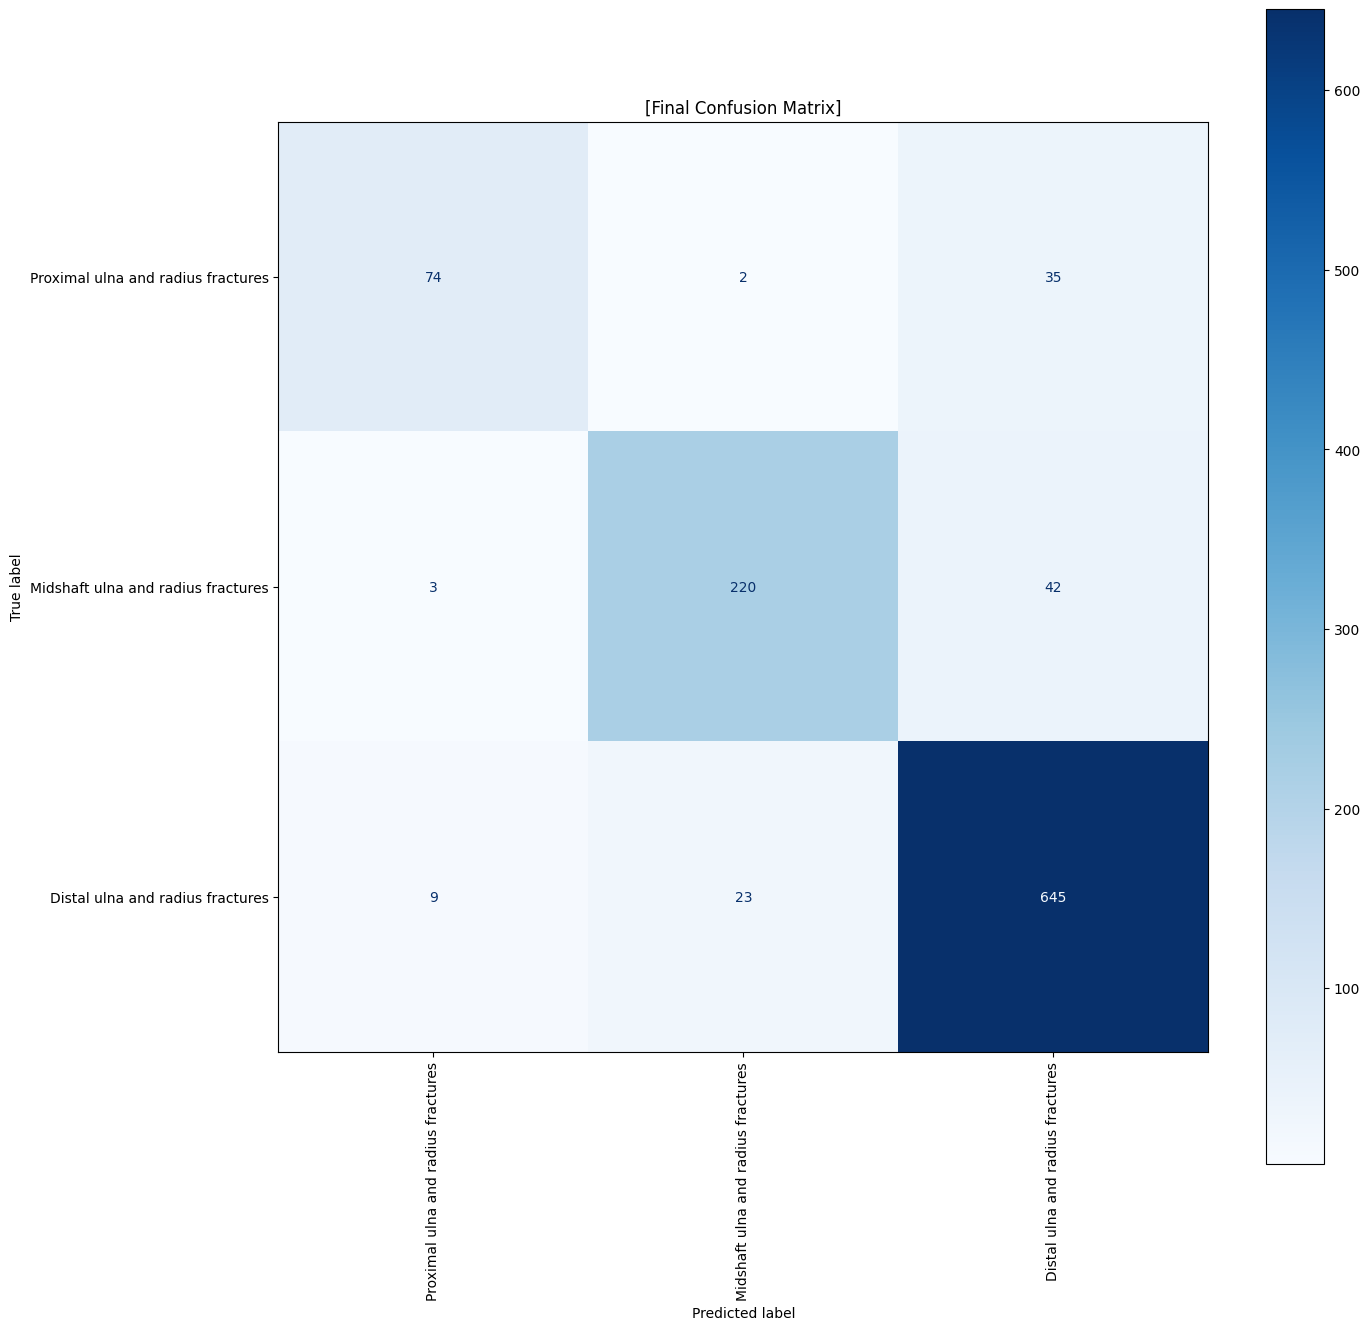


[Classification Report]
                                    precision    recall  f1-score   support

Proximal ulna and radius fractures     0.8605    0.6667    0.7513       111
Midshaft ulna and radius fractures     0.8980    0.8302    0.8627       265
  Distal ulna and radius fractures     0.8934    0.9527    0.9221       677

                          accuracy                         0.8917      1053
                         macro avg     0.8839    0.8165    0.8454      1053
                      weighted avg     0.8910    0.8917    0.8891      1053



In [40]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, auc, roc_curve
import matplotlib.pyplot as plt

save_name = f"ResNet34_Best_SimCLR_Full_Cross.pth"
best_model_path = os.path.join("/home/airl02/Desktop/ParkJeongEun/Model", save_name)

checkpoint = torch.load(best_model_path, map_location=device)
finetune_model.load_state_dict(checkpoint['model_state_dict'])
finetune_model.eval()

targets, preds = [], []

with torch.no_grad():
  for img1, img2, label in ft_test_loader:
    img1 = img1.to(device, non_blocking=True)
    img2 = img2.to(device, non_blocking=True)
    label = label.to(device)

    logits = finetune_model(img1, img2)

    _, pred = torch.max(logits, 1)

    targets.extend(label.cpu().tolist())
    preds.extend(pred.cpu().tolist())

idx_to_cls = ft_test_data.idx_to_cls

target_cls = [idx_to_cls[i] for i in targets]
pred_cls = [idx_to_cls[i] for i in preds]

cm = confusion_matrix(target_cls, pred_cls, labels=list(idx_to_cls.values()))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx_to_cls.values()))

fig, ax = plt.subplots(figsize=(15, 15))
display.plot(cmap='Blues', xticks_rotation='vertical', ax=ax)
plt.title("[Final Confusion Matrix]")
plt.show()

print("\n[Classification Report]")
print(classification_report(
    target_cls,
    pred_cls,
    labels=list(idx_to_cls.values()),
    target_names=list(idx_to_cls.values()),
    digits=4,
    zero_division=0
))

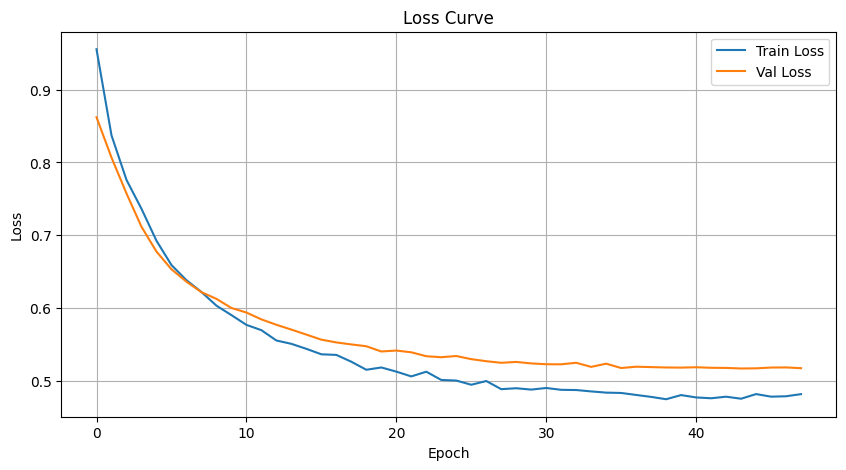

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()